# AICS-106 — Exploratory Data Analysis & Dataset Inventory

**Course:** AICS-106 Deep Learning for Threat Detection
**Author:** Janet Okewu-Ihezie
**Purpose:** Explore the synthetic telemetry datasets before training the deep residual NN and LSTM sequence model. This notebook also serves as the **dataset inventory** deliverable required in Week 1 of the lab pack.

---
## 1. Data Governance & Dataset Inventory Note

**Source:** 100% synthetically generated via `generate_telemetry.py` (custom script, seeded for reproducibility, SEED=42).

**Why synthetic instead of a public dataset (e.g. CICIDS2017):** The lab's ReadMe explicitly lists building *"a synthetic enterprise telemetry generator for network flow and Linux authentication events"* as a required deliverable (see "What Students Will Build"). Public datasets (CICIDS2017, UNSW-NB15, CICIoT2023) are listed separately under "Main Public Dataset Links for **Extension Work**" — i.e. optional, not primary.

**Datasets produced:**
1. `network_flows.csv` — 100,000 rows, 6 classes (Benign, DoS, PortScan, BruteForce, Botnet, WebAttack), 14 features. Used for the deep residual NN.
2. `auth_logs.csv` — 31,243 auth events across 8,000 sessions, session-level binary label (Normal/Anomalous). Used for the LSTM sequence model.

**Known limitations (to be honest about, per the lab's ethics rules):**
- Synthetic data is statistically simpler than real-world traffic; class boundaries are more separable than they would be in production data.
- Class imbalance is deliberately built in to mirror real-world skew, but the *degree* of imbalance is an assumption, not measured from real logs.
- No adversarial or evasive traffic patterns are modeled (e.g. slow-and-low attacks, IP spoofing).


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

flows = pd.read_csv("network_flows.csv")
auth = pd.read_csv("auth_logs.csv")

print("network_flows.csv shape:", flows.shape)
print("auth_logs.csv shape:", auth.shape)

network_flows.csv shape: (100000, 14)
auth_logs.csv shape: (31243, 6)


## 2. Network Flows — Structure & Summary Statistics

In [2]:
flows.head()

,duration,protocol,src_port,dst_port,src_bytes,dst_bytes,packet_count,syn_count,fin_count,avg_packet_size,flow_rate,flow_iat_mean,flow_iat_std,label
0,4.0466,TCP,33591,3306,481.80,174.39,26,1,1,25.24,162.16,0.5790,0.4799,Benign
1,0.0526,TCP,41728,53,892.72,29.83,15,1,1,61.50,17529.64,0.7331,0.1059,Benign
2,0.0888,TCP,11998,35961,9.36,1.42,4,0,0,2.69,121.37,0.0042,0.0325,PortScan
3,0.0754,UDP,54563,54750,7.39,1.30,3,3,0,2.90,115.25,0.0226,0.0037,PortScan
4,3.1007,TCP,31611,8080,27.81,994.48,24,0,0,42.60,329.69,0.1553,0.1653,Benign


In [3]:
flows.info()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 14 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   duration         100000 non-null  float64
 1   protocol         100000 non-null  str    
 2   src_port         100000 non-null  int64  
 3   dst_port         100000 non-null  int64  
 4   src_bytes        100000 non-null  float64
 5   dst_bytes        100000 non-null  float64
 6   packet_count     100000 non-null  int64  
 7   syn_count        100000 non-null  int64  
 8   fin_count        100000 non-null  int64  
 9   avg_packet_size  100000 non-null  float64
 10  flow_rate        100000 non-null  float64
 11  flow_iat_mean    100000 non-null  float64
 12  flow_iat_std     100000 non-null  float64
 13  label            100000 non-null  str    
dtypes: float64(7), int64(5), str(2)
memory usage: 10.7 MB


In [4]:
flows.describe()

,duration,src_port,dst_port,src_bytes,dst_bytes,packet_count,syn_count,fin_count,avg_packet_size,flow_rate,flow_iat_mean,flow_iat_std
count,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,1.000000e+05,100000.000000,100000.000000
mean,1.562694,33341.147200,5575.834770,548.265593,475.600394,91.327820,46.693980,1.216980,52.988431,4.702539e+03,0.409618,0.176134
std,2.248172,18605.638902,12327.430984,1299.582425,1150.558050,172.640521,106.971401,1.517492,96.981725,7.572826e+04,0.647971,0.310947
min,0.000000,1025.000000,4.000000,1.280000,0.460000,0.000000,0.000000,0.000000,0.010000,3.800000e+00,0.000000,0.000000
25%,0.193000,17220.000000,80.000000,27.640000,3.790000,15.000000,1.000000,0.000000,3.950000,1.214700e+02,0.022700,0.010600
50%,0.729250,33370.500000,443.000000,156.895000,124.935000,20.000000,2.000000,1.000000,21.360000,3.969600e+02,0.182900,0.074300
75%,2.055425,49483.250000,5154.750000,553.300000,477.075000,27.000000,4.000000,2.000000,64.420000,1.420898e+03,0.542700,0.220100
max,46.574800,65534.000000,65534.000000,50176.540000,50599.200000,606.000000,378.000000,15.000000,3714.110000,1.468056e+07,16.729600,7.965800


### 2.1 Class Distribution (Class Imbalance Check)

label
Benign        55027
DoS           15084
PortScan      12004
BruteForce     8059
Botnet         5940
WebAttack      3886
Name: count, dtype: int64

Percentage breakdown:
label
Benign        55.03
DoS           15.08
PortScan      12.00
BruteForce     8.06
Botnet         5.94
WebAttack      3.89
Name: count, dtype: float64


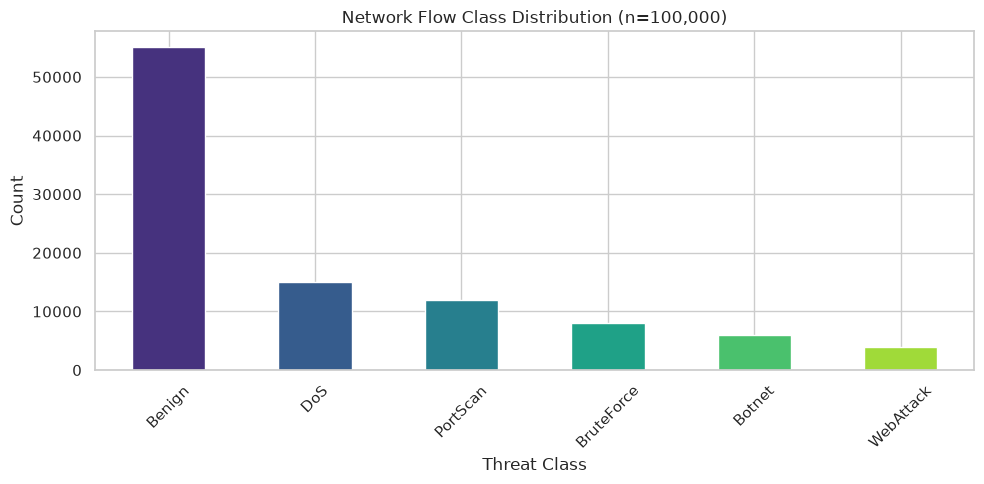

In [5]:
class_counts = flows["label"].value_counts()
class_pct = (class_counts / class_counts.sum() * 100).round(2)

print(class_counts)
print("\nPercentage breakdown:")
print(class_pct)

fig, ax = plt.subplots()
class_counts.plot(kind="bar", ax=ax, color=sns.color_palette("viridis", len(class_counts)))
ax.set_title("Network Flow Class Distribution (n=100,000)")
ax.set_ylabel("Count")
ax.set_xlabel("Threat Class")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("class_distribution.png", dpi=150)
plt.show()

**Observation:** The dataset is heavily imbalanced — Benign traffic makes up 55% of all flows, while WebAttack is under 4%. This matters because a naive model could achieve ~55% accuracy simply by predicting "Benign" every time. This is exactly why accuracy alone will not be used as the evaluation metric later — precision, recall, and F1-score per class will be reported instead (per the lab's ethics requirement).

### 2.2 Feature Distributions by Class

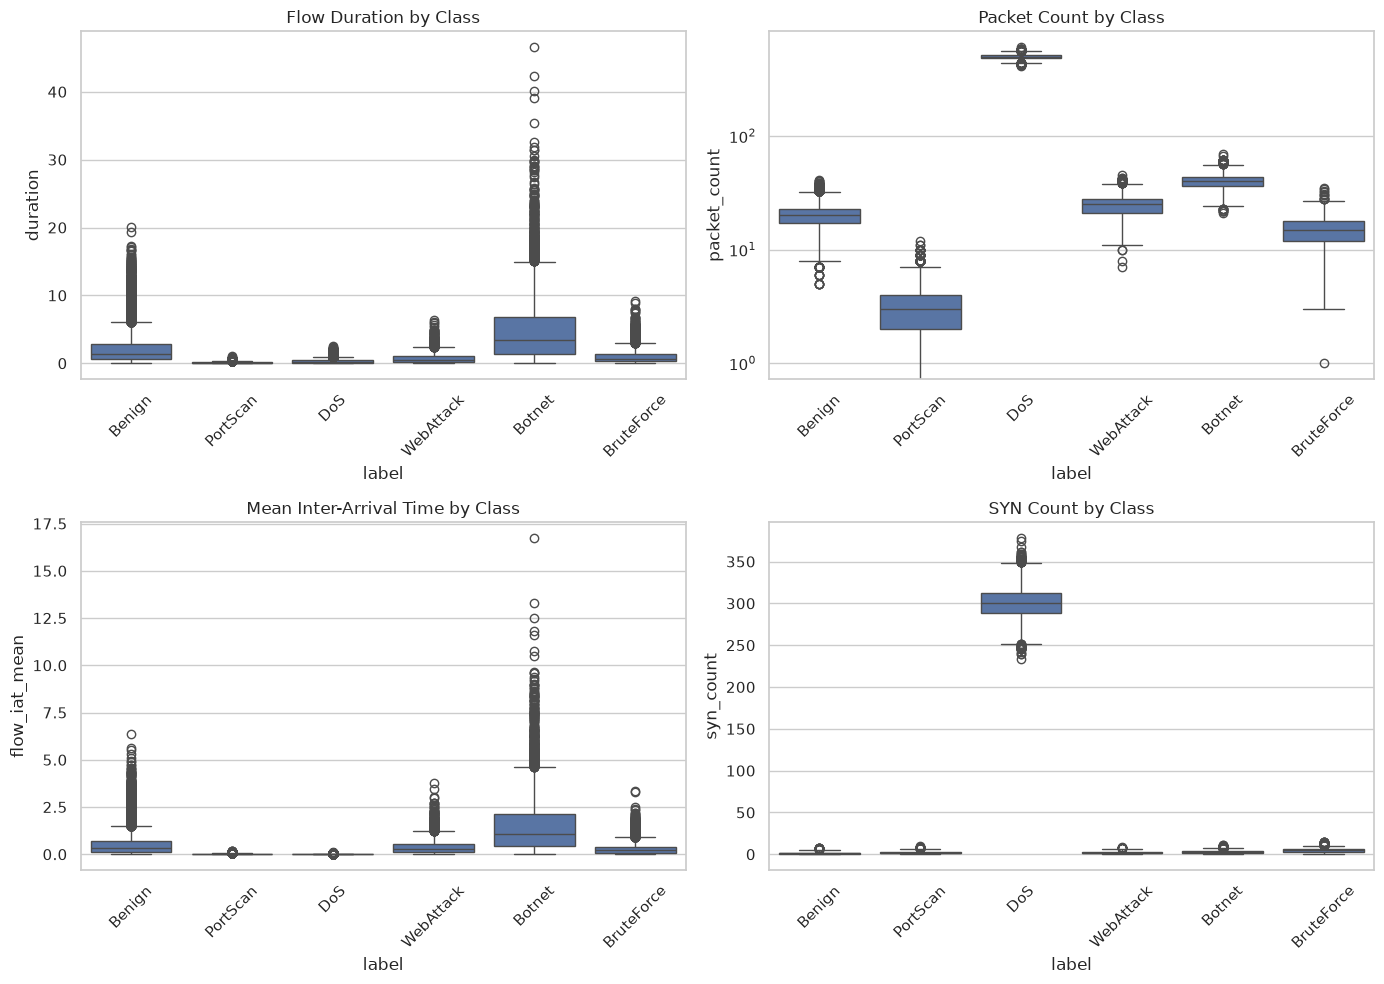

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.boxplot(data=flows, x="label", y="duration", ax=axes[0,0])
axes[0,0].set_title("Flow Duration by Class")
axes[0,0].tick_params(axis='x', rotation=45)

sns.boxplot(data=flows, x="label", y="packet_count", ax=axes[0,1])
axes[0,1].set_title("Packet Count by Class")
axes[0,1].set_yscale("log")
axes[0,1].tick_params(axis='x', rotation=45)

sns.boxplot(data=flows, x="label", y="flow_iat_mean", ax=axes[1,0])
axes[1,0].set_title("Mean Inter-Arrival Time by Class")
axes[1,0].tick_params(axis='x', rotation=45)

sns.boxplot(data=flows, x="label", y="syn_count", ax=axes[1,1])
axes[1,1].set_title("SYN Count by Class")
axes[1,1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig("feature_distributions.png", dpi=150)
plt.show()

**Observation:** DoS flows show extremely high packet counts and SYN counts with very low inter-arrival time — consistent with flooding behavior. PortScan flows show near-zero duration and minimal packets, consistent with reconnaissance sweeps. This confirms the synthetic generator produces features with genuine separating signal, not pure noise — important for justifying that a deep learning model is learning real patterns.

### 2.3 Correlation Heatmap (Numeric Features)

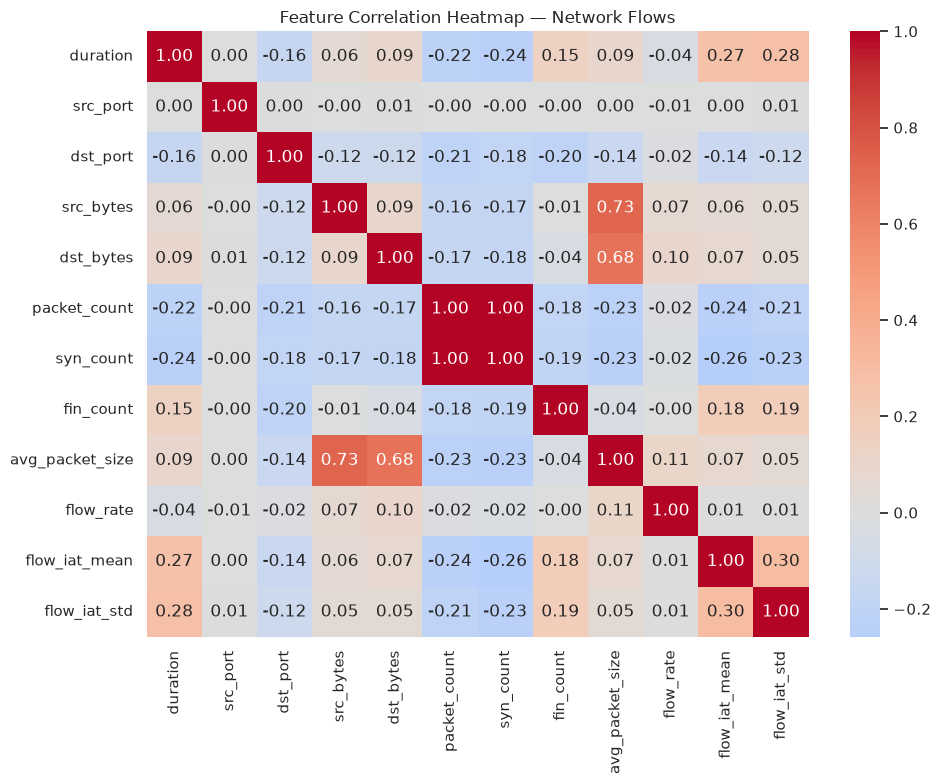

In [7]:
numeric_cols = flows.select_dtypes(include=[np.number]).columns
corr = flows[numeric_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Feature Correlation Heatmap — Network Flows")
plt.tight_layout()
plt.savefig("correlation_heatmap.png", dpi=150)
plt.show()

### 2.4 Protocol Distribution

protocol
TCP     75212
UDP     19728
ICMP     5060
Name: count, dtype: int64


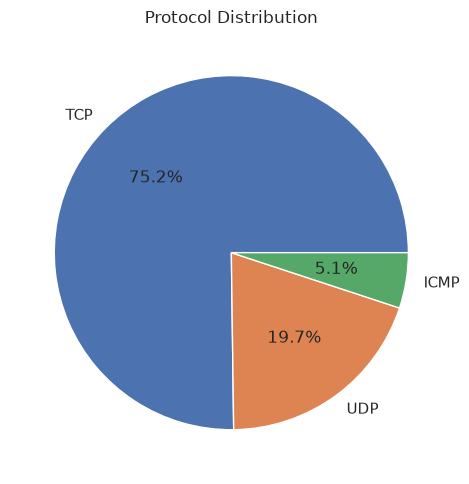

In [8]:
protocol_counts = flows["protocol"].value_counts()
print(protocol_counts)

fig, ax = plt.subplots()
protocol_counts.plot(kind="pie", autopct="%1.1f%%", ax=ax)
ax.set_ylabel("")
ax.set_title("Protocol Distribution")
plt.tight_layout()
plt.savefig("protocol_distribution.png", dpi=150)
plt.show()

## 3. Auth Logs — Structure & Summary Statistics

In [9]:
auth.head(10)

,session_id,user,host,event_type,timestamp,session_label
0,1,user015,host-01.internal,login_success,2026-06-26 10:57:00,0
1,1,user015,host-01.internal,command_exec,2026-06-26 11:04:57,0
2,1,user015,host-01.internal,command_exec,2026-06-26 11:13:51,0
3,1,user015,host-01.internal,command_exec,2026-06-26 11:14:25,0
4,1,user015,host-01.internal,command_exec,2026-06-26 11:16:26,0
5,2,user036,host-08.internal,login_success,2026-06-30 14:27:00,0
6,2,user036,host-08.internal,command_exec,2026-06-30 14:29:44,0
7,2,user036,host-08.internal,sudo_success,2026-06-30 14:34:07,0
8,2,user036,host-08.internal,command_exec,2026-06-30 14:34:57,0
9,2,user036,host-08.internal,command_exec,2026-06-30 14:41:54,0


In [10]:
auth.info()

<class 'pandas.DataFrame'>
RangeIndex: 31243 entries, 0 to 31242
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   session_id     31243 non-null  int64
 1   user           31243 non-null  str  
 2   host           31243 non-null  str  
 3   event_type     31243 non-null  str  
 4   timestamp      31243 non-null  str  
 5   session_label  31243 non-null  int64
dtypes: int64(2), str(4)
memory usage: 1.4 MB


### 3.1 Session-Level Label Distribution

Normal       7036
Anomalous     964
Name: count, dtype: int64

Anomalous session rate: 12.05%


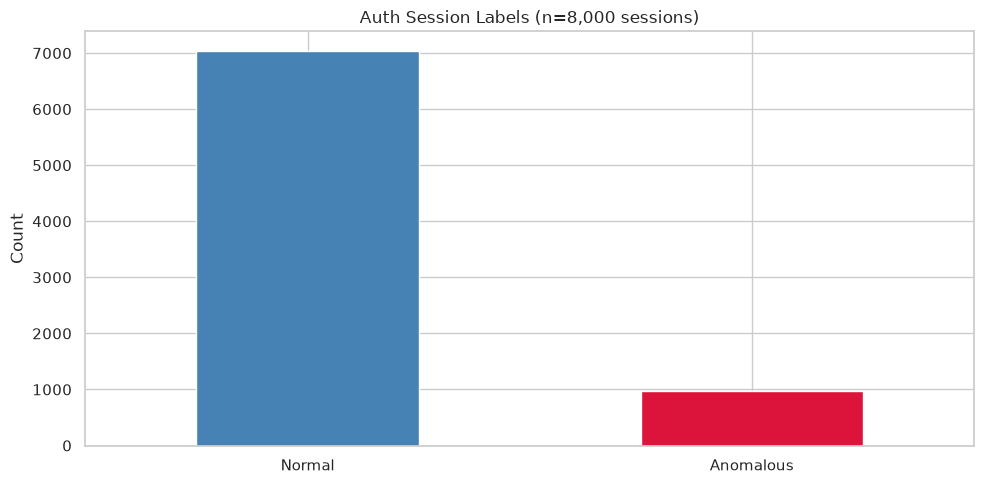

In [11]:
session_labels = auth.groupby("session_id")["session_label"].first()
label_counts = session_labels.value_counts()
label_counts.index = ["Normal", "Anomalous"]

print(label_counts)
print(f"\nAnomalous session rate: {label_counts['Anomalous'] / label_counts.sum() * 100:.2f}%")

fig, ax = plt.subplots()
label_counts.plot(kind="bar", ax=ax, color=["steelblue", "crimson"])
ax.set_title("Auth Session Labels (n=8,000 sessions)")
ax.set_ylabel("Count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("session_label_distribution.png", dpi=150)
plt.show()

### 3.2 Event Type Frequency

event_type
command_exec     12218
login_success     8000
sudo_success      7260
login_failed      2060
logout            1705
Name: count, dtype: int64


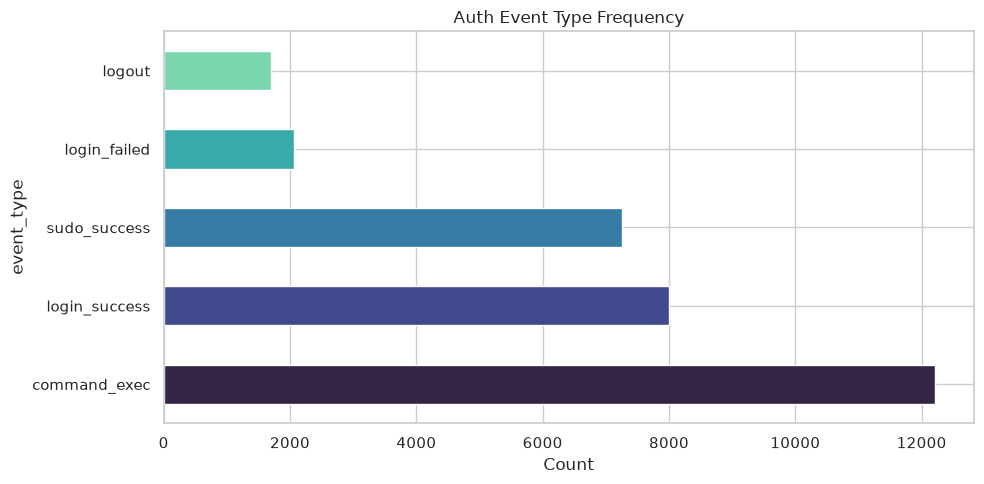

In [12]:
event_counts = auth["event_type"].value_counts()
print(event_counts)

fig, ax = plt.subplots()
event_counts.plot(kind="barh", ax=ax, color=sns.color_palette("mako", len(event_counts)))
ax.set_title("Auth Event Type Frequency")
ax.set_xlabel("Count")
plt.tight_layout()
plt.savefig("event_type_frequency.png", dpi=150)
plt.show()

### 3.3 Session Length Distribution (Events per Session)

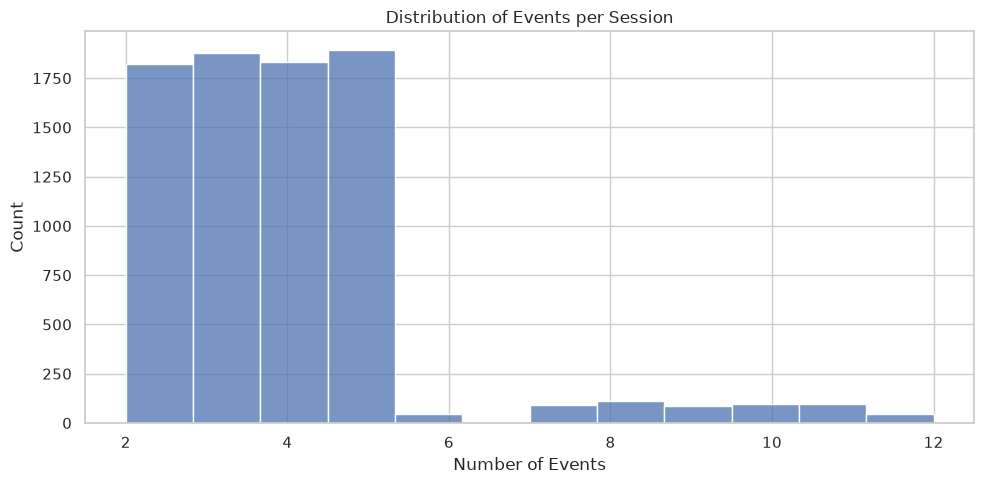

count    8000.000000
mean        3.905375
std         1.841425
min         2.000000
25%         3.000000
50%         4.000000
75%         5.000000
max        12.000000
dtype: float64


In [13]:
session_lengths = auth.groupby("session_id").size()

fig, ax = plt.subplots()
sns.histplot(session_lengths, bins=12, kde=False, ax=ax)
ax.set_title("Distribution of Events per Session")
ax.set_xlabel("Number of Events")
plt.tight_layout()
plt.savefig("session_length_distribution.png", dpi=150)
plt.show()

print(session_lengths.describe())

## 4. Summary of Findings (for Capstone Report)

1. **Class imbalance is real and must be handled** — both in network flows (Benign 55% vs WebAttack 3.9%) and auth sessions (Normal 88% vs Anomalous 12%). Class weighting or SMOTE will be applied during model training, and per-class precision/recall/F1 will be the primary evaluation metrics — not raw accuracy.
2. **Features show genuine class-separating signal** — e.g. DoS traffic clusters at high packet/SYN counts with near-zero inter-arrival time, distinct from Benign traffic. This supports the case for a deep learning approach rather than being an arbitrary choice.
3. **No missing values or corrupted rows** were found in either dataset (synthetic generation guarantees clean data — a limitation to note, since real-world telemetry would require cleaning).
4. **Auth log sessions vary in length** (2 to 12 events), consistent with the three anomalous patterns modeled (credential stuffing, off-hours privilege escalation, rapid sudo abuse) plus normal working-hours sessions.
